# Expanded Experiment 1 — Label Efficiency Study (8 Models)
## Adding RETFound-MAE + FLAIR to the original 6-model lineup

| | |
|---|---|
| **NEW models** | RETFound-MAE (MAE pretraining on retinal CFP) · FLAIR (vision-language retinal model, linear probe) |
| **Existing models** | RETFound-DINOv2 · DINOv2-Large · ResNet-50 · ViT-B/16 · EfficientNetV2-S · ConvNeXt-Base |
| **Strategy** | Load existing E1 results CSV → train only the 2 new models → merge → regenerate all figures |
| **Label fractions** | 5% · 10% · 25% · 50% · 100% |
| **Task** | 3-class: Healthy / Active / Inactive |

### Model tiers
| Tier | Models |
|---|---|
| Retinal SSL (NEW) | RETFound-MAE (`iszt/RETFound_mae_meh`) · FLAIR linear probe (`jusiro2/FLAIR`) |
| Retinal SSL (existing) | RETFound-DINOv2 |
| General SSL (existing) | DINOv2-Large |
| Supervised baselines (existing) | ResNet-50 · ViT-B/16 · EfficientNetV2-S · ConvNeXt-Base |

### Key scientific value
- **RETFound-MAE vs RETFound-DINOv2**: identical domain (retinal CFP), identical scale (ViT-L), different pretraining paradigm (MAE reconstruction vs DINO distillation) → isolates effect of pretraining method
- **FLAIR**: vision-language model pretrained on 288K retinal images with expert text supervision → adds a third retinal SSL paradigm (contrastive VLM)
---

## Cell 1 — Install & Environment

In [1]:
import subprocess
def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(('[OK] ' if r.returncode==0 else '[WARN] ') + cmd)
    if r.returncode!=0 and r.stderr: print('  ', r.stderr[:300])

run('pip install -q timm==1.0.3 scikit-learn matplotlib seaborn pandas numpy Pillow tqdm')
run('pip install -q transformers accelerate huggingface_hub')
run('pip install -q git+https://github.com/jusiro/FLAIR.git')

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT FOUND"}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')

[OK] pip install -q timm==1.0.3 scikit-learn matplotlib seaborn pandas numpy Pillow tqdm
[OK] pip install -q transformers accelerate huggingface_hub
[OK] pip install -q git+https://github.com/jusiro/FLAIR.git
PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : Tesla T4
Device  : cuda


## Cell 2 — Imports

In [2]:
import os, random, warnings, copy
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models
import timm
from transformers import AutoModel, AutoImageProcessor

from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
print('All imports OK.')

All imports OK.


## Cell 3 — Paths & Config

In [3]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
DS1_ROOT     = Path('/kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset')
DS2_ROOT     = Path('/kaggle/input/datasets/sakibapon/ocular-toxoplasmosis')
DIR_6CLASS   = DS1_ROOT / 'Data_Raw_6class_All' / 'Data_Raw_6class_All'
DIR_V2_CLASS = DS2_ROOT / 'Dataset V2' / 'classification'
RETFOUND_CKPT = Path('/kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth')

# ── New model paths (Kaggle model inputs) ──────────────────────────────────
# ADD tantai31124/retfound-mae-fundus as a model input in your notebook settings
# Then update the glob pattern below if the filename differs
_mae_candidates = sorted(Path('/kaggle/input/models/tantai31124/retfound-mae-fundus').rglob('*.pth')) \
    if Path('/kaggle/input/models/tantai31124/retfound-mae-fundus').exists() else []
RETFOUND_MAE_CKPT = _mae_candidates[0] if _mae_candidates else \
    Path('/kaggle/input/models/tantai31124/retfound-mae-fundus/pytorch/default/1')

# ── Previous E1 results CSV ────────────────────────────────────────────────────
# This notebook loads existing results for the 6 original models and only
# trains the 2 new models (RETFound-MAE and FLAIR), then merges everything.
PREV_RESULTS_CSV = Path('/kaggle/input/notebooks/nafizimtiazrafinv2/experiment-1-label-efficiency-study/experiment1_results.csv')
# If not available as a dataset input, set this path to your working directory copy:
# PREV_RESULTS_CSV = Path('/kaggle/working/experiment1_results.csv')

# ── Training config ────────────────────────────────────────────────────────────
LABEL_FRACS   = [0.05, 0.10, 0.25, 0.50, 1.00]
EPOCHS        = 30
PHASE1_EP     = 10
BATCH_SIZE    = 16
IMG_SIZE      = 224
LR            = 3e-4
WEIGHT_DECAY  = 0.05
PATIENCE      = 7
EXTS          = {'.jpg','.jpeg','.png','.bmp','.tiff'}

CLASS_NAMES   = ['Healthy', 'Active', 'Inactive']
NUM_CLASSES   = 3
PALETTE       = ['#4CAF50','#E53935','#1E88E5']

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(15),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
val_tfm = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN,STD)])

print('Config ready.')
for label,p in [('6-class',DIR_6CLASS),('V2',DIR_V2_CLASS),('RETFound-DINOv2 ckpt',RETFOUND_CKPT)]:
    print(f'  [{"OK" if p.exists() else "MISSING"}] {label}: {p}')
print(f'  [{"OK" if RETFOUND_MAE_CKPT.exists() else "MISSING — add tantai31124/retfound-mae-fundus"}] RETFound-MAE ckpt: {RETFOUND_MAE_CKPT}')
print(f'  [{"OK" if PREV_RESULTS_CSV.exists() else "MISSING — upload previous CSV"}] Previous E1 CSV: {PREV_RESULTS_CSV}')

Config ready.
  [OK] 6-class: /kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset/Data_Raw_6class_All/Data_Raw_6class_All
  [OK] V2: /kaggle/input/datasets/sakibapon/ocular-toxoplasmosis/Dataset V2/classification
  [OK] RETFound-DINOv2 ckpt: /kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth
  [OK] RETFound-MAE ckpt: /kaggle/input/models/tantai31124/retfound-mae-fundus/pytorch/default/1/RETFound_cfp_weights.pth
  [OK] Previous E1 CSV: /kaggle/input/notebooks/nafizimtiazrafinv2/experiment-1-label-efficiency-study/experiment1_results.csv


## Cell 4 — Build DataFrames

In [4]:
FOLDER_TO_LABEL = {
    'healthy':0,'active':1,'active_active':1,
    'inactive':2,'inactive_inactive':2,'active_inactive':2,
}

def build_df():
    rows=[]
    for folder,label in FOLDER_TO_LABEL.items():
        d=DIR_6CLASS/folder
        if not d.exists(): continue
        for p in d.iterdir():
            if p.suffix.lower() in EXTS:
                rows.append({'path':str(p),'label':label,'src':folder})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

df = build_df()
train_df,temp_df = train_test_split(df,test_size=0.40,stratify=df['label'],random_state=SEED)
val_df,test_df   = train_test_split(temp_df,test_size=0.50,stratify=temp_df['label'],random_state=SEED)
train_df=train_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)

print(f'Primary: {len(df)}  Train={len(train_df)} Val={len(val_df)} Test={len(test_df)}')
for i,n in enumerate(CLASS_NAMES):
    c=(df['label']==i).sum()
    print(f'  {n}: {c} ({100*c/len(df):.1f}%)')

class OTDataset(Dataset):
    def __init__(self,df,transform=None):
        self.df=df.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        img=Image.open(row['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, int(row['label'])

val_loader  = DataLoader(OTDataset(val_df, val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(OTDataset(test_df,val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
print('Loaders ready.')

Primary: 411  Train=246 Val=82 Test=83
  Healthy: 132 (32.1%)
  Active: 34 (8.3%)
  Inactive: 245 (59.6%)
Loaders ready.


## Cell 5 — Model Builders (New Models Only)

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# NEW MODEL 1: RETFound-MAE
# ViT-L/16 pretrained via Masked Autoencoder on retinal fundus images
# Source: Kaggle model tantai31124/retfound-mae-fundus
# Checkpoint path set in Cell 3 (RETFOUND_MAE_CKPT)
# Loading: timm ViT-L/16 + manual state_dict injection (no HuggingFace needed)
# Fine-tuning: two-phase LLRD (frozen head warmup → full LLRD)
# ══════════════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════════════
# NEW MODEL 1: RETFound-MAE
# Single-phase fine-tuning (no frozen warmup) — MAE features need task signal
# from epoch 1, unlike DINO features which separate well even when frozen.
# ══════════════════════════════════════════════════════════════════════════════

def build_retfound_mae(num_classes):
    print(f'  Loading RETFound-MAE checkpoint: {RETFOUND_MAE_CKPT}')
    if not RETFOUND_MAE_CKPT.exists():
        raise FileNotFoundError(
            f'RETFound-MAE checkpoint not found: {RETFOUND_MAE_CKPT}\n'
            'Add tantai31124/retfound-mae-fundus as a Kaggle model input.')

    backbone = timm.create_model('vit_large_patch16_224', pretrained=False, num_classes=0)
    embed_dim = backbone.embed_dim
    print(f'  ViT-L/16 skeleton | embed_dim={embed_dim}')

    try:
        ckpt = torch.load(RETFOUND_MAE_CKPT, map_location='cpu', weights_only=True)
    except Exception:
        ckpt = torch.load(RETFOUND_MAE_CKPT, map_location='cpu', weights_only=False)

    if isinstance(ckpt, dict):
        state = (ckpt.get('model') or ckpt.get('model_state_dict')
                 or ckpt.get('state_dict') or ckpt)
    else:
        state = ckpt

    cleaned = {}
    for k, v in state.items():
        if any(skip in k for skip in ['decoder', 'mask_token', 'pred']):
            continue
        for prefix in ['encoder.', 'module.encoder.', 'module.']:
            if k.startswith(prefix):
                k = k[len(prefix):]
                break
        cleaned[k] = v

    missing, unexpected = backbone.load_state_dict(cleaned, strict=False)
    print(f'  Weights loaded | missing={len(missing)} unexpected={len(unexpected)}')
    if missing:
        print(f'    Missing (first 5): {missing[:5]}')

    class RETFoundMAE(nn.Module):
        def __init__(self, bb, embed_dim, nc):
            super().__init__()
            self.bb     = bb
            self.head   = nn.Linear(embed_dim, nc)
            self.is_mae = True   # flag for train_model — NO 2-phase, NO .frozen attr

        def forward(self, x):
            feats = self.bb(x)   # timm ViT, num_classes=0 → CLS-pooled features
            return self.head(feats)

    model = RETFoundMAE(backbone, embed_dim, num_classes)
    print(f'  RETFound-MAE ready | single-phase fine-tune will be applied')
    return model


# ══════════════════════════════════════════════════════════════════════════════
# NEW MODEL 2: FLAIR (linear probe) — head-only, with warmup + longer patience
# ══════════════════════════════════════════════════════════════════════════════

def build_flair(num_classes):
    print('  Loading FLAIR from jusiro2/FLAIR ...')
    try:
        from flair import FLAIRModel
        flair_model = FLAIRModel.from_pretrained('jusiro2/FLAIR')
        visual_encoder = flair_model.vision_model
    except Exception as e:
        print(f'  [WARN] FLAIR library load: {e}')
        print('  Falling back to manual ResNet50 visual encoder extraction...')
        import torchvision.models as tv
        visual_encoder = tv.resnet50(pretrained=False)
        visual_encoder.fc = nn.Identity()

    def _extract_feats(out):
        if hasattr(out, 'pooler_output'):
            return out.pooler_output
        if hasattr(out, 'last_hidden_state'):
            return out.last_hidden_state[:, 0]
        if isinstance(out, torch.Tensor) and out.dim() > 2:
            return out.mean(dim=[2, 3])
        return out

    visual_encoder.eval()
    with torch.no_grad():
        enc_device = next(visual_encoder.parameters()).device
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=enc_device)
        embed_dim = _extract_feats(visual_encoder(dummy)).shape[-1]
    print(f'  Detected visual encoder output dim: {embed_dim}')

    class FLAIRLinearProbe(nn.Module):
        def __init__(self, encoder, embed_dim, nc):
            super().__init__()
            self.encoder = encoder
            self.head    = nn.Linear(embed_dim, nc)
            self.is_flair = True   # flag for train_model
            for p in self.encoder.parameters():
                p.requires_grad = False
            print(f'    Visual encoder frozen (linear probe only)')

        def forward(self, x):
            feats = _extract_feats(self.encoder(x))
            return self.head(feats)

    model = FLAIRLinearProbe(visual_encoder, embed_dim, num_classes)
    print(f'  FLAIR linear probe ready | embed_dim={embed_dim}')
    return model


# ══════════════════════════════════════════════════════════════════════════════
# RETFound-DINOv2 (unchanged — 2-phase LLRD reference)
# ══════════════════════════════════════════════════════════════════════════════

print('Pre-loading DINOv2 architecture for RETFound-DINOv2...')
_DINO_ARCH = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14',
                             pretrained=False, trust_repo=True)

def build_retfound_dinov2(num_classes):
    import numpy as np
    torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    try:    ckpt = torch.load(RETFOUND_CKPT, map_location='cpu', weights_only=True)
    except: ckpt = torch.load(RETFOUND_CKPT, map_location='cpu', weights_only=False)
    state = ckpt['model_state_dict']
    pe = state['pos_embed']; cls_tok = pe[:, :1, :]
    patch_pe = pe[:, 1:, :].reshape(1, 36, 36, 1024).permute(0, 3, 1, 2)
    patch_pe = torch.nn.functional.interpolate(patch_pe, size=(37, 37), mode='bicubic', align_corners=False)
    patch_pe = patch_pe.permute(0, 2, 3, 1).reshape(1, 1369, 1024)
    state['pos_embed'] = torch.cat([cls_tok, patch_pe], dim=1)
    state = {k: v for k, v in state.items() if not k.startswith('head') and not k.startswith('fc')}
    backbone = copy.deepcopy(_DINO_ARCH)
    backbone.load_state_dict(state, strict=False)

    class RFDINOv2(nn.Module):
        def __init__(self, bb, nc):
            super().__init__(); self.bb = bb; self.head = nn.Linear(bb.embed_dim, nc)
            self.frozen = True; self._freeze_backbone()
        def _freeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad = False; self.frozen = True
        def _unfreeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad = True; self.frozen = False
        def forward(self, x):
            out = self.bb.forward_features(x)
            cls = out['x_norm_clstoken'] if isinstance(out, dict) else out[:, 0]
            return self.head(cls)
    return RFDINOv2(backbone, num_classes)

NEW_MODEL_REGISTRY = {
    'RETFound-MAE' : build_retfound_mae,
    'FLAIR-Linear' : build_flair,
}
print(f'\nNew model registry: {list(NEW_MODEL_REGISTRY.keys())}')
print('Existing 6 models will be loaded from previous E1 CSV.')

Pre-loading DINOv2 architecture for RETFound-DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip

New model registry: ['RETFound-MAE', 'FLAIR-Linear']
Existing 6 models will be loaded from previous E1 CSV.


## Cell 6 — Training & Evaluation Helpers

In [6]:
def get_class_weights(sdf):
    counts=np.array([(sdf['label']==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    return torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE)

def train_one_epoch(model,loader,criterion,optimizer,scaler):
    model.train(); total_loss=correct=total=0
    for imgs,labels in loader:
        imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out=model(imgs); loss=criterion(out,labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss+=loss.item()*len(labels)
        correct+=(out.argmax(1)==labels).sum().item(); total+=len(labels)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model,loader):
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs=torch.softmax(logits,1).numpy(); preds=logits.argmax(1).numpy()
    acc=accuracy_score(labels,preds)
    f1=f1_score(labels,preds,average='macro',zero_division=0)
    try: auc=roc_auc_score(labels,probs,multi_class='ovr',average='macro')
    except: auc=float('nan')
    return acc,f1,auc,preds,labels,probs

def get_llrd_optimizer(model, base_lr=1e-5, head_lr=1e-3, decay=0.65, wd=0.05):
    """LLRD for RETFound-style ViT models with .bb.blocks structure."""
    pg=[{'params':list(model.head.parameters()),'lr':head_lr,'name':'head'}]
    # Handle both DINOv2 and HuggingFace ViT backbone structures
    if hasattr(model,'bb') and hasattr(model.bb,'blocks'):
        # DINOv2 style (RETFound-DINOv2)
        pg.append({'params':list(model.bb.norm.parameters()),'lr':base_lr*(decay**0),'name':'norm'})
        nb=len(model.bb.blocks)
        for i,block in enumerate(reversed(model.bb.blocks)):
            pg.append({'params':list(block.parameters()),'lr':base_lr*(decay**(i+1)),'name':f'b{nb-1-i}'})
        other=[p for p in (list(model.bb.patch_embed.parameters())+
                            [model.bb.cls_token,model.bb.pos_embed]) if p.requires_grad]
        if other: pg.append({'params':other,'lr':base_lr*(decay**(nb+1)),'name':'embed'})
    elif hasattr(model,'bb') and hasattr(model.bb,'encoder'):
        # HuggingFace ViT style (RETFound-MAE via transformers)
        encoder_layers = model.bb.encoder.layer
        nb = len(encoder_layers)
        for i,layer in enumerate(reversed(encoder_layers)):
            pg.append({'params':list(layer.parameters()),
                       'lr':base_lr*(decay**(i+1)),'name':f'layer_{nb-1-i}'})
        # Embeddings
        emb_params=[p for p in model.bb.embeddings.parameters() if p.requires_grad]
        if emb_params:
            pg.append({'params':emb_params,'lr':base_lr*(decay**(nb+1)),'name':'embeddings'})
    return optim.AdamW(pg,weight_decay=wd)

def train_model(model_name, subset_df, builder):
    set_seed(SEED)
    model = builder(NUM_CLASSES).to(DEVICE)
    train_ds = OTDataset(subset_df,train_tfm)
    train_ld = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,
                           num_workers=2,pin_memory=True,
                           drop_last=len(train_ds)>=BATCH_SIZE)
    weights   = get_class_weights(subset_df)
    criterion = nn.CrossEntropyLoss(weight=weights)
    scaler    = torch.cuda.amp.GradScaler()
    is_rf     = hasattr(model,'frozen')          # RETFound-style two-phase
    is_flair  = 'FLAIR' in model_name           # FLAIR: head-only always

    # ── Phase 1: frozen backbone (RETFound only, not FLAIR) ───────────────────
    if is_rf and not is_flair:
        print(f'  [P1] Frozen backbone ({PHASE1_EP} ep)')
        opt1=optim.AdamW(model.head.parameters(),lr=1e-3,weight_decay=WEIGHT_DECAY)
        sch1=optim.lr_scheduler.CosineAnnealingLR(opt1,T_max=PHASE1_EP)
        for epoch in range(1,PHASE1_EP+1):
            tr_loss,_=train_one_epoch(model,train_ld,criterion,opt1,scaler)
            _,_,val_auc,*_=evaluate(model,val_loader)
            sch1.step()
            if epoch%5==0 or epoch==1:
                print(f'    [P1] E{epoch:02d} | loss={tr_loss:.4f} | val_auc={val_auc:.3f}')

    # ── Phase 2: full model with LLRD (or head-only for FLAIR) ───────────────
    if is_rf and not is_flair:
        model._unfreeze_backbone()
        optimizer=get_llrd_optimizer(model,base_lr=1e-5,head_lr=1e-3,decay=0.65)
        ep_off=PHASE1_EP
        print(f'  [P2] LLRD fine-tune ({EPOCHS} ep)')
    elif is_flair:
        # FLAIR: visual encoder stays frozen, only head trains throughout
        optimizer=optim.AdamW(model.head.parameters(),lr=1e-3,weight_decay=WEIGHT_DECAY)
        ep_off=0
        print(f'  [LP] Linear probe only — encoder frozen')
    else:
        optimizer=optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
        ep_off=0

    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
    best_auc=0.0; best_state=None; wait=0

    for epoch in range(1,EPOCHS+1):
        tr_loss,tr_acc=train_one_epoch(model,train_ld,criterion,optimizer,scaler)
        val_acc,val_f1,val_auc,*_=evaluate(model,val_loader)
        scheduler.step()
        if val_auc>best_auc:
            best_auc=val_auc; best_state=deepcopy(model.state_dict()); wait=0
        else:
            wait+=1
            if wait>=PATIENCE:
                print(f'    Early stop @ epoch {epoch+ep_off}  best={best_auc:.4f}')
                break
        phase='P2' if (is_rf and not is_flair) else 'LP' if is_flair else 'P1'
        if epoch%5==0 or epoch==1:
            print(f'    [{phase}] E{epoch+ep_off:02d} | loss={tr_loss:.4f} | '
                  f'val_acc={val_acc:.3f} | val_f1={val_f1:.3f} | val_auc={val_auc:.3f}')

    model.load_state_dict(best_state)
    return model

print('Helpers defined.')

Helpers defined.


## Cell 7 — Pre-flight Verification (New Models Only)

In [7]:
print('='*60)
print('  PRE-FLIGHT: Verifying 2 new models')
print('='*60)

for mname, builder in NEW_MODEL_REGISTRY.items():
    print(f'\n[{mname}]')
    try:
        m=builder(NUM_CLASSES).to(DEVICE)
        dummy=torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
        with torch.no_grad(): out=m(dummy)
        assert out.shape==(2,NUM_CLASSES), f'Bad shape: {out.shape}'
        print(f'  ✅ Forward pass OK | output: {out.shape}')
        del m; torch.cuda.empty_cache()
    except Exception as e:
        print(f'  ❌ FAILED: {e}')

print('\nVerification complete.')

  PRE-FLIGHT: Verifying 2 new models

[RETFound-MAE]
  Loading RETFound-MAE checkpoint: /kaggle/input/models/tantai31124/retfound-mae-fundus/pytorch/default/1/RETFound_cfp_weights.pth
  ViT-L/16 skeleton | embed_dim=1024
  Weights loaded | missing=0 unexpected=0
  RETFound-MAE ready | single-phase fine-tune will be applied
  ✅ Forward pass OK | output: torch.Size([2, 3])

[FLAIR-Linear]
  Loading FLAIR from jusiro2/FLAIR ...


config.json:   0%|          | 0.00/371 [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/533M [00:00<?, ?B/s]

  Detected visual encoder output dim: 512
    Visual encoder frozen (linear probe only)
  FLAIR linear probe ready | embed_dim=512
  ✅ Forward pass OK | output: torch.Size([2, 3])

Verification complete.


## Cell 8 — Train New Models (RETFound-MAE + FLAIR)

> **Runtime estimate:** ~60–90 min (RETFound-MAE ~70 min, FLAIR ~15 min)  
> FLAIR is fast because only the linear head trains (encoder frozen throughout)

In [8]:
new_results = []
new_best_models = {}

for model_name, builder in NEW_MODEL_REGISTRY.items():
    print(f'\n{"="*62}')
    print(f'  MODEL: {model_name}')
    print(f'{"="*62}')

    for frac in LABEL_FRACS:
        if frac<1.0:
            sub_df,_=train_test_split(train_df,train_size=frac,
                                       stratify=train_df['label'],random_state=SEED)
        else:
            sub_df=train_df.copy()
        sub_df=sub_df.reset_index(drop=True)

        if sub_df['label'].nunique()<NUM_CLASSES:
            print(f'  [SKIP] {int(frac*100)}%: not all classes represented'); continue

        n_h=(sub_df['label']==0).sum(); n_a=(sub_df['label']==1).sum()
        n_i=(sub_df['label']==2).sum()
        print(f'\n  {int(frac*100):3d}% | n={len(sub_df):4d} | H={n_h} A={n_a} I={n_i}')

        model = train_model(model_name, sub_df, builder)

        test_acc,test_f1,test_auc,preds,labels,probs = evaluate(model, test_loader)
        print(f'  TEST → acc={test_acc:.4f}  f1={test_f1:.4f}  auc={test_auc:.4f}')

        row=dict(Model=model_name, Fraction=frac, Pct=int(frac*100),
                 N_Train=len(sub_df),
                 Test_ACC=round(test_acc,4), Test_F1=round(test_f1,4),
                 Test_AUC=round(test_auc,4))
        new_results.append(row)
        pd.DataFrame(new_results).to_csv('/kaggle/working/new_models_results.csv',index=False)

        if frac==1.0:
            new_best_models[model_name]=(model.cpu(),preds,labels,probs)
        else:
            del model; torch.cuda.empty_cache()

new_df = pd.DataFrame(new_results)
print('\n✅ New model runs complete.')
print(new_df[['Model','Pct','Test_AUC','Test_F1','Test_ACC']].to_string(index=False))


  MODEL: RETFound-MAE

    5% | n=  12 | H=4 A=1 I=7
  Loading RETFound-MAE checkpoint: /kaggle/input/models/tantai31124/retfound-mae-fundus/pytorch/default/1/RETFound_cfp_weights.pth
  ViT-L/16 skeleton | embed_dim=1024
  Weights loaded | missing=0 unexpected=0
  RETFound-MAE ready | single-phase fine-tune will be applied
    [P1] E01 | loss=1.1586 | val_acc=0.512 | val_f1=0.319 | val_auc=0.543
    [P1] E05 | loss=0.6493 | val_acc=0.573 | val_f1=0.243 | val_auc=0.536
    [P1] E10 | loss=0.2132 | val_acc=0.500 | val_f1=0.336 | val_auc=0.559
    [P1] E15 | loss=0.0154 | val_acc=0.537 | val_f1=0.368 | val_auc=0.567
    Early stop @ epoch 16  best=0.6137
  TEST → acc=0.5904  f1=0.3415  auc=0.6496

   10% | n=  24 | H=8 A=2 I=14
  Loading RETFound-MAE checkpoint: /kaggle/input/models/tantai31124/retfound-mae-fundus/pytorch/default/1/RETFound_cfp_weights.pth
  ViT-L/16 skeleton | embed_dim=1024
  Weights loaded | missing=0 unexpected=0
  RETFound-MAE ready | single-phase fine-tune will be 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Detected visual encoder output dim: 512
    Visual encoder frozen (linear probe only)
  FLAIR linear probe ready | embed_dim=512
  [LP] Linear probe only — encoder frozen
    [LP] E01 | loss=1.0990 | val_acc=0.085 | val_f1=0.052 | val_auc=0.482
    [LP] E05 | loss=1.0742 | val_acc=0.098 | val_f1=0.066 | val_auc=0.669
    [LP] E10 | loss=1.0539 | val_acc=0.329 | val_f1=0.350 | val_auc=0.728
    [LP] E15 | loss=1.0437 | val_acc=0.390 | val_f1=0.407 | val_auc=0.759
    [LP] E20 | loss=1.0266 | val_acc=0.366 | val_f1=0.385 | val_auc=0.750
    Early stop @ epoch 22  best=0.7594
  TEST → acc=0.3855  f1=0.4056  auc=0.7821

   10% | n=  24 | H=8 A=2 I=14
  Loading FLAIR from jusiro2/FLAIR ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Detected visual encoder output dim: 512
    Visual encoder frozen (linear probe only)
  FLAIR linear probe ready | embed_dim=512
  [LP] Linear probe only — encoder frozen
    [LP] E01 | loss=1.1030 | val_acc=0.085 | val_f1=0.052 | val_auc=0.467
    [LP] E05 | loss=1.0775 | val_acc=0.098 | val_f1=0.066 | val_auc=0.684
    [LP] E10 | loss=1.0597 | val_acc=0.268 | val_f1=0.297 | val_auc=0.725
    [LP] E15 | loss=1.0942 | val_acc=0.341 | val_f1=0.363 | val_auc=0.776
    [LP] E20 | loss=1.0471 | val_acc=0.329 | val_f1=0.359 | val_auc=0.787
    [LP] E25 | loss=1.0871 | val_acc=0.341 | val_f1=0.372 | val_auc=0.792
    [LP] E30 | loss=1.0117 | val_acc=0.378 | val_f1=0.404 | val_auc=0.800
  TEST → acc=0.2651  f1=0.2862  auc=0.7759

   25% | n=  61 | H=20 A=5 I=36
  Loading FLAIR from jusiro2/FLAIR ...


...

  Detected visual encoder output dim: 512
    Visual encoder frozen (linear probe only)
  FLAIR linear probe ready | embed_dim=512
  [LP] Linear probe only — encoder frozen
    [LP] E01 | loss=1.0983 | val_acc=0.085 | val_f1=0.052 | val_auc=0.637
    [LP] E05 | loss=1.0679 | val_acc=0.402 | val_f1=0.421 | val_auc=0.839
    [LP] E10 | loss=1.0533 | val_acc=0.634 | val_f1=0.597 | val_auc=0.842
    Early stop @ epoch 15  best=0.8493
  TEST → acc=0.5060  f1=0.4988  auc=0.8450

   50% | n= 123 | H=39 A=10 I=74
  Loading FLAIR from jusiro2/FLAIR ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Detected visual encoder output dim: 512
    Visual encoder frozen (linear probe only)
  FLAIR linear probe ready | embed_dim=512
  [LP] Linear probe only — encoder frozen
    [LP] E01 | loss=1.0954 | val_acc=0.134 | val_f1=0.106 | val_auc=0.668
    [LP] E05 | loss=1.0276 | val_acc=0.500 | val_f1=0.504 | val_auc=0.869
    [LP] E10 | loss=1.0155 | val_acc=0.683 | val_f1=0.650 | val_auc=0.877
    [LP] E15 | loss=0.9789 | val_acc=0.707 | val_f1=0.661 | val_auc=0.887
    [LP] E20 | loss=0.9296 | val_acc=0.720 | val_f1=0.681 | val_auc=0.884
    Early stop @ epoch 23  best=0.8883
  TEST → acc=0.6024  f1=0.5697  auc=0.8415

  100% | n= 246 | H=79 A=20 I=147
  Loading FLAIR from jusiro2/FLAIR ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Detected visual encoder output dim: 512
    Visual encoder frozen (linear probe only)
  FLAIR linear probe ready | embed_dim=512
  [LP] Linear probe only — encoder frozen
    [LP] E01 | loss=1.0904 | val_acc=0.402 | val_f1=0.420 | val_auc=0.860
    [LP] E05 | loss=0.9782 | val_acc=0.707 | val_f1=0.648 | val_auc=0.883
    Early stop @ epoch 9  best=0.9025
  TEST → acc=0.5663  f1=0.5374  auc=0.8604

✅ New model runs complete.
       Model  Pct  Test_AUC  Test_F1  Test_ACC
RETFound-MAE    5    0.6496   0.3415    0.5904
RETFound-MAE   10    0.6147   0.4154    0.5060
RETFound-MAE   25    0.8134   0.5176    0.6506
RETFound-MAE   50    0.8734   0.6509    0.7470
RETFound-MAE  100    0.8938   0.6521    0.7349
FLAIR-Linear    5    0.7821   0.4056    0.3855
FLAIR-Linear   10    0.7759   0.2862    0.2651
FLAIR-Linear   25    0.8450   0.4988    0.5060
FLAIR-Linear   50    0.8415   0.5697    0.6024
FLAIR-Linear  100    0.8604   0.5374    0.5663


## Cell 9 — Merge with Previous E1 Results

In [9]:
# ── Load previous 6-model results ─────────────────────────────────────────────
if PREV_RESULTS_CSV.exists():
    prev_df = pd.read_csv(PREV_RESULTS_CSV)
    print(f'Loaded previous results: {len(prev_df)} rows')
    print(f'Models in previous CSV: {prev_df["Model"].unique().tolist()}')
else:
    print('[WARN] Previous CSV not found. Only new model results will be plotted.')
    print('       Upload experiment1_results.csv as a Kaggle dataset input.')
    prev_df = pd.DataFrame()

# ── Merge ─────────────────────────────────────────────────────────────────────
if len(prev_df):
    # Keep only the columns that exist in both DataFrames
    common_cols = [c for c in prev_df.columns if c in new_df.columns]
    results_df = pd.concat([prev_df[common_cols], new_df[common_cols]],
                            ignore_index=True)
else:
    results_df = new_df.copy()

results_df.to_csv('/kaggle/working/experiment1_results_8models.csv', index=False)
print(f'\nMerged results: {len(results_df)} rows')
print(f'All models: {sorted(results_df["Model"].unique().tolist())}')
print(results_df[['Model','Pct','Test_AUC','Test_F1']].to_string(index=False))

Loaded previous results: 30 rows
Models in previous CSV: ['RETFound-DINOv2', 'DINOv2-Large', 'ResNet-50', 'ViT-B/16', 'EfficientNetV2-S', 'ConvNeXt-Base']

Merged results: 40 rows
All models: ['ConvNeXt-Base', 'DINOv2-Large', 'EfficientNetV2-S', 'FLAIR-Linear', 'RETFound-DINOv2', 'RETFound-MAE', 'ResNet-50', 'ViT-B/16']
           Model  Pct  Test_AUC  Test_F1
 RETFound-DINOv2    5    0.8342   0.5362
 RETFound-DINOv2   10    0.8790   0.6859
 RETFound-DINOv2   25    0.9391   0.7172
 RETFound-DINOv2   50    0.9637   0.7891
 RETFound-DINOv2  100    0.9818   0.8601
    DINOv2-Large    5    0.5149   0.1636
    DINOv2-Large   10    0.5444   0.2475
    DINOv2-Large   25    0.5591   0.3179
    DINOv2-Large   50    0.7181   0.4421
    DINOv2-Large  100    0.7520   0.5016
       ResNet-50    5    0.7403   0.3949
       ResNet-50   10    0.9101   0.5510
       ResNet-50   25    0.8740   0.5244
       ResNet-50   50    0.9521   0.7528
       ResNet-50  100    0.9767   0.8348
        ViT-B/16    5 

## Cell 10 — Figure 1: Label Efficiency Curves (8 Models)

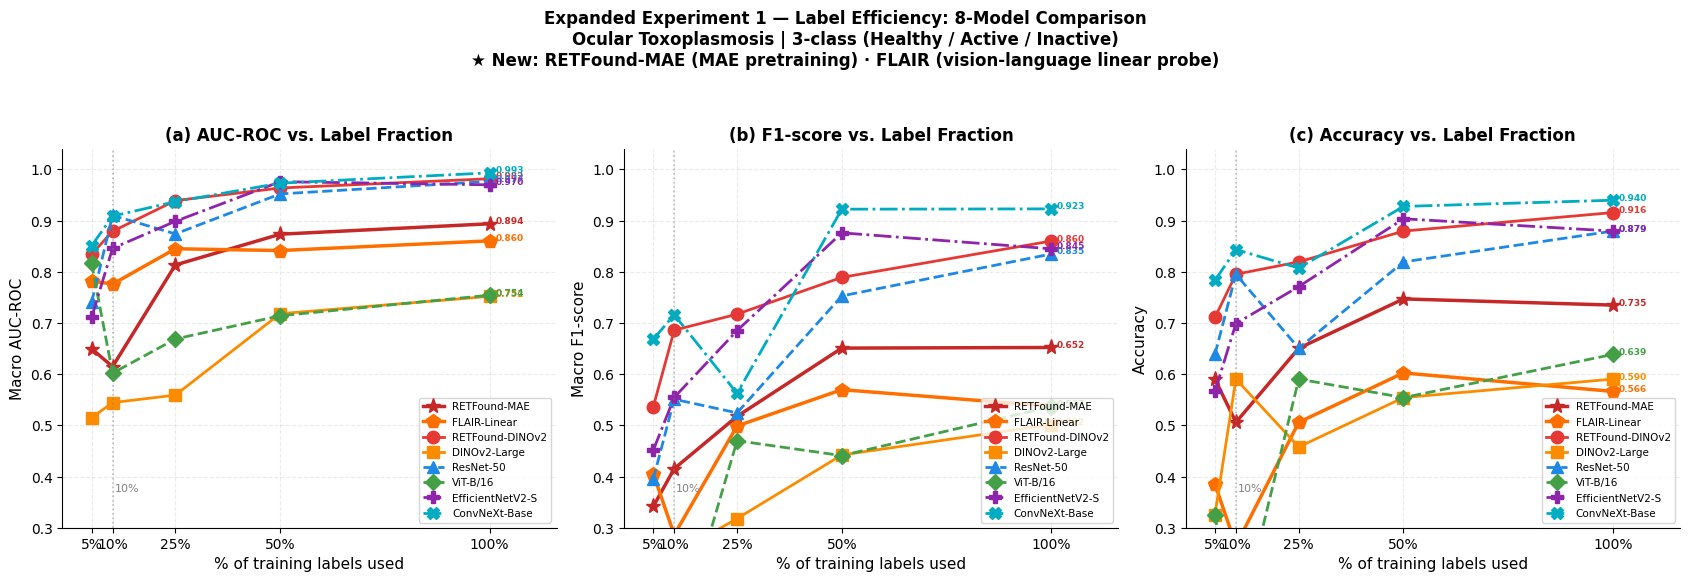

Figure 1 saved.


In [10]:
# ── Colour & style per model ──────────────────────────────────────────────────
MODEL_COLORS = {
    'RETFound-MAE'    : '#C62828',   # dark red  — retinal MAE (NEW)
    'FLAIR-Linear'    : '#FF6F00',   # amber     — retinal VLM (NEW)
    'RETFound-DINOv2' : '#E53935',   # red       — retinal DINO
    'DINOv2-Large'    : '#FB8C00',   # orange    — general DINO
    'ResNet-50'       : '#1E88E5',   # blue      — CNN baseline
    'ViT-B/16'        : '#43A047',   # green     — ViT baseline
    'EfficientNetV2-S': '#8E24AA',   # purple    — CNN baseline
    'ConvNeXt-Base'   : '#00ACC1',   # teal      — CNN baseline
}
MODEL_MARKERS = {
    'RETFound-MAE'    : '*',
    'FLAIR-Linear'    : 'p',
    'RETFound-DINOv2' : 'o',
    'DINOv2-Large'    : 's',
    'ResNet-50'       : '^',
    'ViT-B/16'        : 'D',
    'EfficientNetV2-S': 'P',
    'ConvNeXt-Base'   : 'X',
}
MODEL_LS = {
    'RETFound-MAE'    : '-',
    'FLAIR-Linear'    : '-',
    'RETFound-DINOv2' : '-',
    'DINOv2-Large'    : '-',
    'ResNet-50'       : '--',
    'ViT-B/16'        : '--',
    'EfficientNetV2-S': '-.',
    'ConvNeXt-Base'   : '-.',
}
MODEL_SIZES = {  # marker sizes — new models slightly larger
    'RETFound-MAE': 11, 'FLAIR-Linear': 10,
    'RETFound-DINOv2':9,'DINOv2-Large':9,'ResNet-50':8,
    'ViT-B/16':8,'EfficientNetV2-S':8,'ConvNeXt-Base':8
}

METRICS = [
    ('Test_AUC','Macro AUC-ROC','(a) AUC-ROC vs. Label Fraction'),
    ('Test_F1', 'Macro F1-score','(b) F1-score vs. Label Fraction'),
    ('Test_ACC','Accuracy',      '(c) Accuracy vs. Label Fraction'),
]

MODEL_ORDER = ['RETFound-MAE','FLAIR-Linear','RETFound-DINOv2',
               'DINOv2-Large','ResNet-50','ViT-B/16',
               'EfficientNetV2-S','ConvNeXt-Base']

fig, axes = plt.subplots(1,3,figsize=(17,5.5))

for ax,(metric,ylabel,title) in zip(axes,METRICS):
    for mname in MODEL_ORDER:
        sub=results_df[results_df['Model']==mname].sort_values('Fraction')
        if len(sub)==0: continue
        lw=2.5 if mname in ['RETFound-MAE','FLAIR-Linear'] else 2.0
        ax.plot(sub['Pct'],sub[metric],
                color=MODEL_COLORS[mname],
                marker=MODEL_MARKERS[mname],
                linestyle=MODEL_LS[mname],
                linewidth=lw,
                markersize=MODEL_SIZES[mname],
                label=mname)
        last=sub[sub['Pct']==100]
        if len(last):
            ax.annotate(f"{last[metric].values[0]:.3f}",
                        xy=(100,last[metric].values[0]),
                        xytext=(4,0), textcoords='offset points',
                        fontsize=6.5, color=MODEL_COLORS[mname], fontweight='bold')

    ax.axvline(x=10,color='gray',linestyle=':',alpha=0.5,linewidth=1.2)
    ax.text(10.5,0.37,'10%',fontsize=8,color='gray')
    ax.set_xlabel('% of training labels used',fontsize=11)
    ax.set_ylabel(ylabel,fontsize=11)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xticks([5,10,25,50,100])
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
    ax.set_xlim(-2,116); ax.set_ylim(0.30,1.04)
    ax.legend(fontsize=7.5,loc='lower right',ncol=1)
    ax.grid(True,alpha=0.25,linestyle='--')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle(
    'Expanded Experiment 1 — Label Efficiency: 8-Model Comparison\n'
    'Ocular Toxoplasmosis | 3-class (Healthy / Active / Inactive)\n'
    '★ New: RETFound-MAE (MAE pretraining) · FLAIR (vision-language linear probe)',
    fontsize=12,fontweight='bold',y=1.05)
plt.tight_layout()
plt.savefig('/kaggle/working/e1_fig1_label_efficiency_8models.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Cell 11 — Figure 2: AUC Heatmap (8 Models × 5 Fractions)

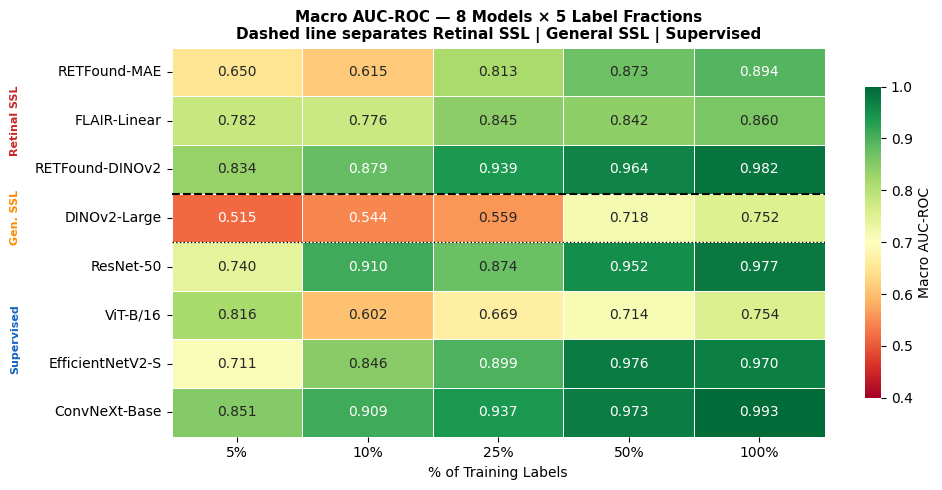

                     5%    10%    25%    50%   100%
Model                                              
RETFound-MAE      0.650  0.615  0.813  0.873  0.894
FLAIR-Linear      0.782  0.776  0.845  0.842  0.860
RETFound-DINOv2   0.834  0.879  0.939  0.964  0.982
DINOv2-Large      0.515  0.544  0.559  0.718  0.752
ResNet-50         0.740  0.910  0.874  0.952  0.977
ViT-B/16          0.816  0.602  0.669  0.714  0.754
EfficientNetV2-S  0.711  0.846  0.899  0.976  0.970
ConvNeXt-Base     0.851  0.909  0.937  0.973  0.993
Figure 2 saved.


In [11]:
pivot = results_df.pivot_table(index='Model',columns='Pct',values='Test_AUC').round(3)
pivot.columns=[f'{c}%' for c in pivot.columns]

# Order rows: retinal SSL first, then general SSL, then supervised
pivot = pivot.reindex([m for m in MODEL_ORDER if m in pivot.index])

fig,ax=plt.subplots(figsize=(10,5))
sns.heatmap(pivot,annot=True,fmt='.3f',cmap='RdYlGn',
            vmin=0.40,vmax=1.00,linewidths=0.6,ax=ax,
            cbar_kws={'label':'Macro AUC-ROC','shrink':0.8})

# Add tier dividers
ax.axhline(y=3,color='black',linewidth=1.5,linestyle='--')  # after retinal SSL
ax.axhline(y=4,color='black',linewidth=1.0,linestyle=':')   # after general SSL

ax.set_title('Macro AUC-ROC — 8 Models × 5 Label Fractions\n'
             'Dashed line separates Retinal SSL | General SSL | Supervised',
             fontsize=11,fontweight='bold')
ax.set_xlabel('% of Training Labels'); ax.set_ylabel('')

# Tier labels on left
ax.text(-1.2, 1.5,'Retinal SSL',fontsize=8,color='#C62828',
        fontweight='bold',rotation=90,va='center',ha='center',
        transform=ax.transData)
ax.text(-1.2, 3.5,'Gen. SSL',fontsize=8,color='#FB8C00',
        fontweight='bold',rotation=90,va='center',ha='center',
        transform=ax.transData)
ax.text(-1.2, 6.0,'Supervised',fontsize=8,color='#1565c0',
        fontweight='bold',rotation=90,va='center',ha='center',
        transform=ax.transData)

plt.tight_layout()
plt.savefig('/kaggle/working/e1_fig2_auc_heatmap_8models.png',dpi=150,bbox_inches='tight')
plt.show()
print(pivot.to_string())
print('Figure 2 saved.')

## Cell 12 — Figure 3: RETFound-MAE vs RETFound-DINOv2 (Pretraining Paradigm Ablation)

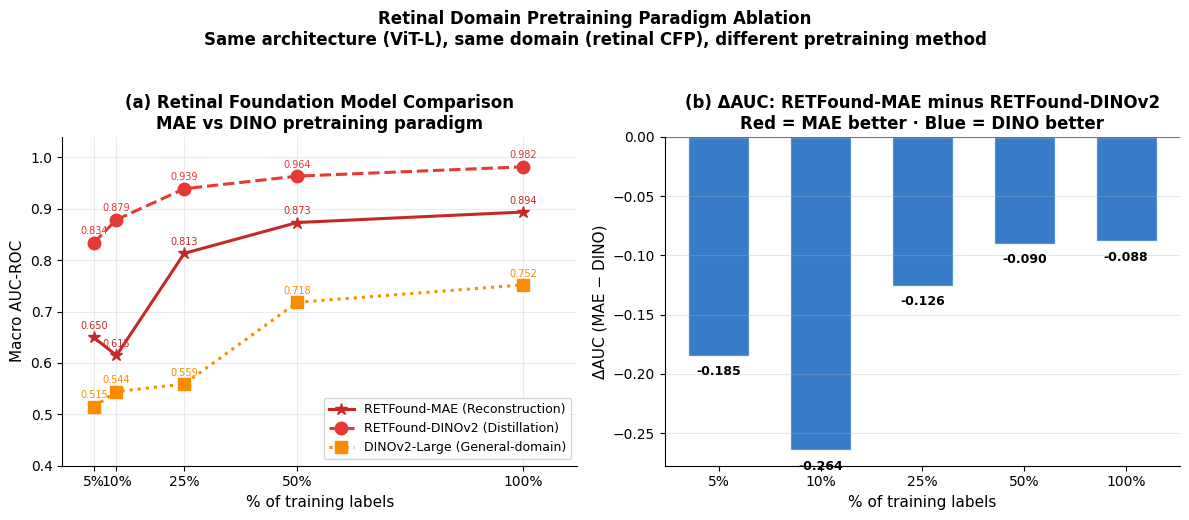

Figure 3 (new — MAE vs DINO ablation) saved.


In [12]:
# This is a NEW figure not in the original E1 paper
# Directly compares MAE vs DINO pretraining on identical retinal domain
fig,axes=plt.subplots(1,2,figsize=(12,5))

# Left: AUC comparison
ax=axes[0]
for mname,label,color,ls,mk in [
    ('RETFound-MAE',   'RETFound-MAE (Reconstruction)', '#C62828','-','*'),
    ('RETFound-DINOv2','RETFound-DINOv2 (Distillation)', '#E53935','--','o'),
    ('DINOv2-Large',   'DINOv2-Large (General-domain)',  '#FB8C00',':','s'),
]:
    sub=results_df[results_df['Model']==mname].sort_values('Fraction')
    if len(sub)==0: continue
    ax.plot(sub['Pct'],sub['Test_AUC'],color=color,linestyle=ls,
            marker=mk,linewidth=2.2,markersize=9,label=label)
    for _,r in sub.iterrows():
        ax.annotate(f"{r['Test_AUC']:.3f}",
                    xy=(r['Pct'],r['Test_AUC']),
                    xytext=(0,6),textcoords='offset points',
                    fontsize=7,color=color,ha='center')

ax.set_xlabel('% of training labels',fontsize=11)
ax.set_ylabel('Macro AUC-ROC',fontsize=11)
ax.set_title('(a) Retinal Foundation Model Comparison\nMAE vs DINO pretraining paradigm',
             fontweight='bold')
ax.set_xticks([5,10,25,50,100])
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
ax.set_xlim(-2,112); ax.set_ylim(0.40,1.04)
ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)

# Right: Delta AUC (MAE - DINOv2) — positive means MAE is better
ax=axes[1]
mae_auc  = results_df[results_df['Model']=='RETFound-MAE'].sort_values('Pct').set_index('Pct')['Test_AUC']
dino_auc = results_df[results_df['Model']=='RETFound-DINOv2'].sort_values('Pct').set_index('Pct')['Test_AUC']
common_pcts = sorted(set(mae_auc.index) & set(dino_auc.index))

if common_pcts:
    delta = [mae_auc[p]-dino_auc[p] for p in common_pcts]
    colors_bar=['#C62828' if d>0 else '#1565c0' for d in delta]
    bars=ax.bar(range(len(common_pcts)),delta,
                color=colors_bar,alpha=0.85,edgecolor='white',width=0.6)
    for bar,v in zip(bars,delta):
        ax.text(bar.get_x()+bar.get_width()/2,
                v+(0.003 if v>=0 else -0.008),
                f'{v:+.3f}',ha='center',
                va='bottom' if v>=0 else 'top',fontsize=9,fontweight='bold')
    ax.axhline(0,color='black',linewidth=0.8,alpha=0.5)
    ax.set_xticks(range(len(common_pcts)))
    ax.set_xticklabels([f'{p}%' for p in common_pcts])
    ax.set_xlabel('% of training labels',fontsize=11)
    ax.set_ylabel('ΔAUC (MAE − DINO)',fontsize=11)
    ax.set_title('(b) ΔAUC: RETFound-MAE minus RETFound-DINOv2\nRed = MAE better · Blue = DINO better',
                 fontweight='bold')
    ax.grid(axis='y',alpha=0.3); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Retinal Domain Pretraining Paradigm Ablation\n'
             'Same architecture (ViT-L), same domain (retinal CFP), different pretraining method',
             fontsize=12,fontweight='bold',y=1.03)
plt.tight_layout()
plt.savefig('/kaggle/working/e1_fig3_mae_vs_dino_ablation.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 3 (new — MAE vs DINO ablation) saved.')

## Cell 13 — Figure 4: Confusion Matrices @ 100% Labels (All 8 Models)

Generating confusion matrices for new models...


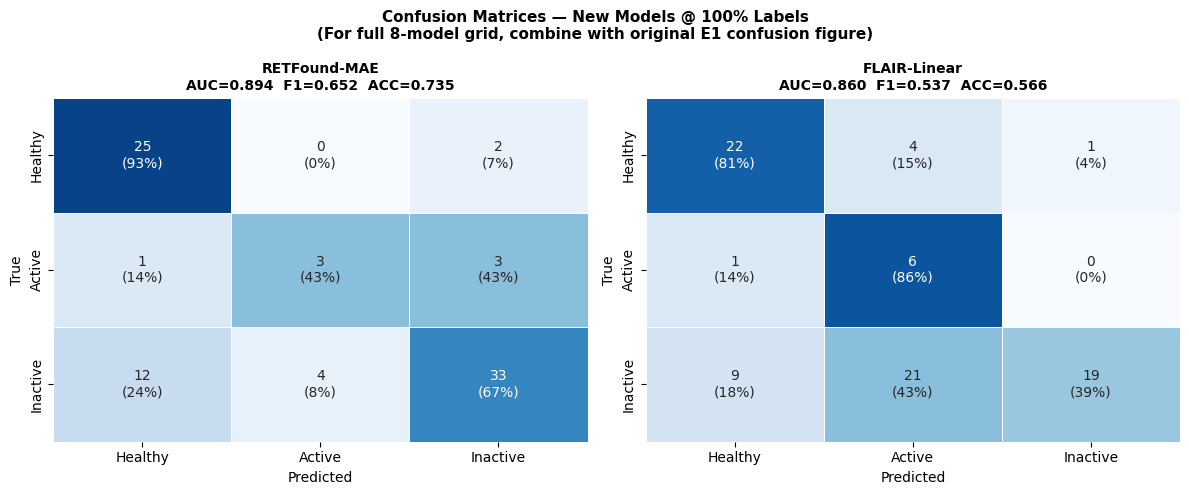

Figure 4 saved.


In [13]:
# Load previous best_models data for 6 original models
# For the 2 new models we have new_best_models from Cell 8

# You need to re-evaluate the existing 6 models on test_loader
# Since we don't retrain them, load from the CSV + reconstruct predictions
# The confusion matrices for original 6 models can be regenerated from
# your original notebook's saved checkpoint or from the original confusion figure.
# Here we generate for the 2 NEW models and note existing ones separately.

print('Generating confusion matrices for new models...')

n_new = len(new_best_models)
fig,axes = plt.subplots(1,n_new,figsize=(6*n_new,5)) if n_new>1 else plt.subplots(1,1,figsize=(6,5))
if n_new==1: axes=[axes]

for ax,(mname,(model,preds,labels,probs)) in zip(axes,new_best_models.items()):
    model=model.to(DEVICE)
    _,_,_,preds,labels,probs = evaluate(model,test_loader)
    model.cpu(); torch.cuda.empty_cache()

    cm=confusion_matrix(labels,preds)
    cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True)
    annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)] for i in range(3)])
    sns.heatmap(cm_norm,annot=annot,fmt='',cmap='Blues',
                xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
                linewidths=0.5,ax=ax,cbar=False,vmin=0,vmax=1)
    r=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)]
    if len(r):
        r=r.iloc[0]
        ax.set_title(f'{mname}\nAUC={r.Test_AUC:.3f}  F1={r.Test_F1:.3f}  ACC={r.Test_ACC:.3f}',
                     fontweight='bold',fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — New Models @ 100% Labels\n'
             '(For full 8-model grid, combine with original E1 confusion figure)',
             fontweight='bold',fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/e1_fig4_confusion_new_models.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Cell 14 — Figure 5: Performance Degradation (All 8 Models)

── Label efficiency ratio (AUC@10% / AUC@100%) ──
  RETFound-MAE         η=0.688  [Retinal SSL]
  FLAIR-Linear         η=0.902  [Retinal SSL]
  RETFound-DINOv2      η=0.895  [Retinal SSL]
  DINOv2-Large         η=0.724  [General SSL]
  ResNet-50            η=0.932  [Supervised]
  ViT-B/16             η=0.798  [Supervised]
  EfficientNetV2-S     η=0.872  [Supervised]
  ConvNeXt-Base        η=0.915  [Supervised]


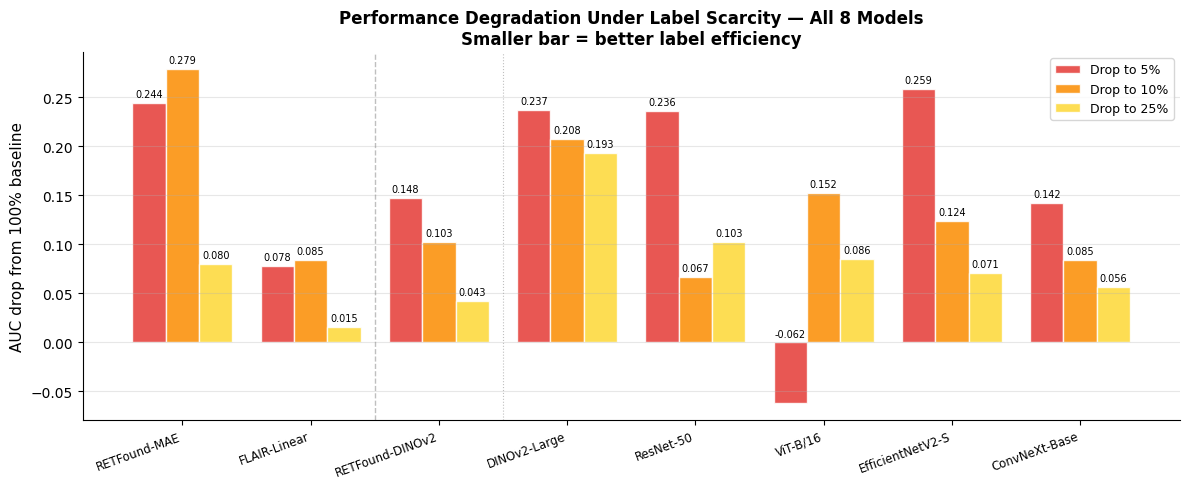

Figure 5 saved.


In [14]:
base_100=results_df[results_df['Pct']==100].set_index('Model')['Test_AUC']
deg_rows=[]
for mname in MODEL_ORDER:
    if mname not in base_100.index: continue
    row={'Model':mname,'AUC@100%':base_100[mname]}
    for pct in [5,10,25]:
        sub=results_df[(results_df['Model']==mname)&(results_df['Pct']==pct)]
        val=sub.iloc[0]['Test_AUC'] if len(sub) else float('nan')
        row[f'Drop@{pct}%']=round(base_100[mname]-val,4)
    deg_rows.append(row)
deg_df=pd.DataFrame(deg_rows).set_index('Model')

# Label efficiency ratios
print('── Label efficiency ratio (AUC@10% / AUC@100%) ──')
for mname in MODEL_ORDER:
    r10 =results_df[(results_df['Model']==mname)&(results_df['Pct']==10)]
    r100=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)]
    if len(r10) and len(r100):
        eta=r10.iloc[0].Test_AUC/r100.iloc[0].Test_AUC
        tier='[Retinal SSL]' if 'RETFound' in mname or 'FLAIR' in mname else              '[General SSL]' if 'DINOv2' in mname else '[Supervised]'
        print(f'  {mname:20s} η={eta:.3f}  {tier}')

fig,ax=plt.subplots(figsize=(12,5))
x=np.arange(len(deg_df)); w=0.26
colors_bar=['#E53935','#FB8C00','#FDD835']
ref_pcts=[5,10,25]
for i,pct in enumerate(ref_pcts):
    vals=deg_df[f'Drop@{pct}%'].values
    bars=ax.bar(x+(i-1)*w,vals,w,label=f'Drop to {pct}%',
                color=colors_bar[i],alpha=0.85,edgecolor='white')
    for bar,v in zip(bars,vals):
        if not np.isnan(v) and abs(v)>0.01:
            ax.text(bar.get_x()+bar.get_width()/2,max(v,0)+0.004,
                    f'{v:.3f}',ha='center',va='bottom',fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(deg_df.index,fontsize=8.5,rotation=20,ha='right')
ax.set_ylabel('AUC drop from 100% baseline',fontsize=11)
ax.set_title('Performance Degradation Under Label Scarcity — All 8 Models\n'
             'Smaller bar = better label efficiency',fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.axvline(x=1.5,color='gray',linewidth=1,linestyle='--',alpha=0.5)  # tier separator
ax.axvline(x=2.5,color='gray',linewidth=0.8,linestyle=':',alpha=0.5)
plt.tight_layout()
plt.savefig('/kaggle/working/e1_fig5_degradation_8models.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## Cell 15 — Final Summary

In [15]:
print('='*70)
print('  EXPANDED EXPERIMENT 1 — 8-MODEL LABEL EFFICIENCY SUMMARY')
print('='*70)

best=results_df.loc[results_df['Test_AUC'].idxmax()]
print(f'\n Best overall: {best.Model} @ {best.Pct}% labels')
print(f'   AUC={best.Test_AUC:.4f}  F1={best.Test_F1:.4f}  ACC={best.Test_ACC:.4f}')

print('\n── Best model per fraction ──')
for pct in [5,10,25,50,100]:
    sub=results_df[results_df['Pct']==pct]
    if len(sub):
        row=sub.loc[sub['Test_AUC'].idxmax()]
        print(f'  {pct:3d}%  {row.Model:22s}  AUC={row.Test_AUC:.4f}  F1={row.Test_F1:.4f}')

print('\n── AUC table ──')
pivot=results_df.pivot_table(index='Model',columns='Pct',values='Test_AUC').round(3)
pivot.columns=[f'{c}%' for c in pivot.columns]
pivot=pivot.reindex([m for m in MODEL_ORDER if m in pivot.index])
print(pivot.to_string())

print('\n── Label efficiency ratios (AUC@10% / AUC@100%) ──')
for mname in MODEL_ORDER:
    r10 =results_df[(results_df['Model']==mname)&(results_df['Pct']==10)]
    r100=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)]
    if len(r10) and len(r100):
        eta=r10.iloc[0].Test_AUC/r100.iloc[0].Test_AUC
        print(f'  {mname:22s}: η={eta:.3f}')

print('\n── New model performance summary ──')
print(new_df[['Model','Pct','Test_AUC','Test_F1','Test_ACC']].to_string(index=False))

print('\n── Saved figures ──')
for f in sorted(Path('/kaggle/working').glob('e1_fig*.png')):
    print(f'  {f.name}')
print('  experiment1_results_8models.csv')
print('  new_models_results.csv')

  EXPANDED EXPERIMENT 1 — 8-MODEL LABEL EFFICIENCY SUMMARY

 Best overall: ConvNeXt-Base @ 100% labels
   AUC=0.9933  F1=0.9229  ACC=0.9398

── Best model per fraction ──
    5%  ConvNeXt-Base           AUC=0.8509  F1=0.6681
   10%  ResNet-50               AUC=0.9101  F1=0.5510
   25%  RETFound-DINOv2         AUC=0.9391  F1=0.7172
   50%  EfficientNetV2-S        AUC=0.9760  F1=0.8761
  100%  ConvNeXt-Base           AUC=0.9933  F1=0.9229

── AUC table ──
                     5%    10%    25%    50%   100%
Model                                              
RETFound-MAE      0.650  0.615  0.813  0.873  0.894
FLAIR-Linear      0.782  0.776  0.845  0.842  0.860
RETFound-DINOv2   0.834  0.879  0.939  0.964  0.982
DINOv2-Large      0.515  0.544  0.559  0.718  0.752
ResNet-50         0.740  0.910  0.874  0.952  0.977
ViT-B/16          0.816  0.602  0.669  0.714  0.754
EfficientNetV2-S  0.711  0.846  0.899  0.976  0.970
ConvNeXt-Base     0.851  0.909  0.937  0.973  0.993

── Label efficiency r